# Lab 8: Summarizing the Data Frame

## Objective

The objective of this lab is to read the Treatment dataset into a Pandas DataFrame and summarize the `Relative Fitness` values by treatment groups. The lab also analyzes the data by both `Treatment` and `Group` to identify patterns, differences, and similarities across categories.

In [1]:
# Import the pandas library
# Pandas is used for reading, organizing, grouping, and summarizing tabular data

import pandas as pd

In [2]:
# Read the Treatment dataset into a Pandas DataFrame
# The file is stored in the same folder as this notebook

df = pd.read_excel("Lab 8 - Treatment.xls")

# Display the first five rows of the dataset
df.head()

,Group,Treatment,Replicate,RelativeFitness
0,BKB,Tube,1,0.869963
1,BKB,Tube,2,1.000363
2,BKB,Tube,3,0.982935
3,BAC,Tube,1,0.810392
4,BAC,Tube,2,0.795107


## Step 2: Check the DataFrame Structure

Before grouping or summarizing the data, it is important to understand the structure of the DataFrame. In this step, we check the column names, number of rows and columns, and basic information about the dataset.

In [3]:
# Display the shape of the DataFrame
# This shows the number of rows and columns in the dataset

df.shape

(64, 4)

In [4]:
# Display summary information about the DataFrame
# This includes column names, data types, and non-null values

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Group            64 non-null     object 
 1   Treatment        64 non-null     object 
 2   Replicate        64 non-null     int64  
 3   RelativeFitness  64 non-null     float64
dtypes: float64(1), int64(1), object(2)
memory usage: 2.1+ KB


In [5]:
df.shape
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Group            64 non-null     object 
 1   Treatment        64 non-null     object 
 2   Replicate        64 non-null     int64  
 3   RelativeFitness  64 non-null     float64
dtypes: float64(1), int64(1), object(2)
memory usage: 2.1+ KB


Group              0
Treatment          0
Replicate          0
RelativeFitness    0
dtype: int64

## Step 3: Group the Dataset by Treatment

In this step, the dataset is grouped by the `Treatment` column. Grouping allows us to summarize and compare the `RelativeFitness` values for each treatment category.

In [6]:
# Group the DataFrame by the Treatment column

treatment_group = df.groupby("Treatment")

In [7]:
# Display the number of records in each Treatment group

treatment_group.size()

Treatment
Dish    32
Tube    32
dtype: int64

In [8]:
# Display the mean RelativeFitness value for each Treatment group
# This gives an initial comparison between treatments

treatment_group["RelativeFitness"].mean()

Treatment
Dish    1.456359
Tube    0.929589
Name: RelativeFitness, dtype: float64

In [9]:
treatment_group.size()
treatment_group["RelativeFitness"].mean()

Treatment
Dish    1.456359
Tube    0.929589
Name: RelativeFitness, dtype: float64

## Step 4: Analyze Relative Fitness Distribution by Treatment

The `describe()` method provides important summary statistics, including count, mean, standard deviation, minimum, quartiles, and maximum values. Here, it is applied to the `RelativeFitness` column after grouping the dataset by `Treatment`.

In [11]:
# Use describe() to summarize RelativeFitness values for each Treatment group

treatment_summary = treatment_group["RelativeFitness"].describe()

# Display the treatment summary
treatment_summary

,count,mean,std,min,25%,50%,75%,max
Treatment,,,,,,,,
Dish,32.0,1.456359,0.184792,0.955221,1.429005,1.510884,1.581340,1.699276
Tube,32.0,0.929589,0.050153,0.795107,0.915050,0.939089,0.953505,1.000363


In [12]:
# Round the summary values to make the output easier to read

treatment_summary.round(4)

,count,mean,std,min,25%,50%,75%,max
Treatment,,,,,,,,
Dish,32.0,1.4564,0.1848,0.9552,1.4290,1.5109,1.5813,1.6993
Tube,32.0,0.9296,0.0502,0.7951,0.9151,0.9391,0.9535,1.0004


### Observation

The summary statistics show the distribution of `RelativeFitness` values for each treatment group. The mean value helps compare the average relative fitness between treatments. The standard deviation shows how much variation exists within each treatment group. The minimum and maximum values show the range of relative fitness values observed in each treatment.

Based on the summary, the treatment group with the higher mean `RelativeFitness` appears to have better overall fitness performance. The standard deviation also helps determine whether the values are closely grouped or more spread out within each treatment.

## Step 5: Group the Dataset by Treatment and Group

In this step, the dataset is grouped by both `Treatment` and `Group`. This allows us to compare the `RelativeFitness` values for each group within each treatment type.

In [13]:
# Group the DataFrame by both Treatment and Group

treatment_group_summary = df.groupby(["Treatment", "Group"])

In [14]:
# Count the number of records for each Treatment and Group combination

treatment_group_summary.size()

Treatment  Group
Dish       BAC      2
           BKB      3
           DOS      3
           ECO      3
           ETH      3
           FIT      3
           H2W      3
           HHE      3
           JDK      3
           PPP      3
           SWI      3
Tube       BAC      2
           BKB      3
           DOS      3
           ECO      3
           ETH      3
           FIT      3
           H2W      3
           HHE      3
           JDK      3
           PPP      3
           SWI      3
dtype: int64

In [15]:
# Use describe() to summarize RelativeFitness for each Treatment and Group combination

treatment_group_describe = treatment_group_summary["RelativeFitness"].describe()

# Display the summary
treatment_group_describe

count      mean       std       min       25%       50%  \
Treatment Group                                                            
Dish      BAC      2.0  1.633628  0.026313  1.615022  1.624325  1.633628   
          BKB      3.0  1.315682  0.179156  1.152544  1.219815  1.287085   
          DOS      3.0  1.587148  0.006740  1.581325  1.583456  1.585587   
          ECO      3.0  1.561197  0.124910  1.456057  1.492157  1.528258   
          ETH      3.0  1.482941  0.124571  1.364456  1.418004  1.471552   
          FIT      3.0  1.001960  0.041853  0.955221  0.984953  1.014686   
          H2W      3.0  1.525228  0.014052  1.511499  1.518050  1.524601   
          HHE      3.0  1.424773  0.085070  1.329803  1.390162  1.450522   
          JDK      3.0  1.546707  0.036218  1.510268  1.528710  1.547152   
          PPP      3.0  1.547974  0.036531  1.508969  1.531269  1.553568   
          SWI      3.0  1.451796  0.079652  1.362556  1.419848  1.477141   
Tube      BAC      2.0  0.802749  0.010808  0.795107  0.798928  0.802749   
          BKB      3.0  0.951087  0.070794  0.869963  0.926449  0.982935   
          DOS      3.0  0.945595  0.005768  0.939563  0.942864  0.946164   
          ECO      3.0  0.971033  0.029120  0.939479  0.958115  0.976750   
          ETH      3.0  0.934431  0.022169  0.914288  0.922555  0.930821   
          FIT      3.0  0.956410  0.038808  0.926698  0.934457  0.942216   
          H2W      3.0  0.902636  0.043792  0.853906  0.884605  0.915304   
          HHE      3.0  0.939615  0.015305  0.922486  0.933450  0.944414   
          JDK      3.0  0.890721  0.036479  0.849204  0.877263  0.905323   
          PPP      3.0  0.970277  0.020897  0.948767  0.960166  0.971565   
          SWI      3.0  0.918647  0.009692  0.909023  0.913768  0.918514   

                      75%       max  
Treatment Group                      
Dish      BAC    1.642931  1.652234  
          BKB    1.397250  1.507415  
          DOS    1.590059  1.594531  
          ECO    1.613767  1.699276  
          ETH    1.542184  1.612816  
          FIT    1.025329  1.035973  
          H2W    1.532092  1.539582  
          HHE    1.472258  1.493994  
          JDK    1.564926  1.582701  
          PPP    1.567477  1.581386  
          SWI    1.496417  1.515692  
Tube      BAC    0.806570  0.810392  
          BKB    0.991649  1.000363  
          DOS    0.948610  0.951057  
          ECO    0.986811  0.996871  
          ETH    0.944502  0.958183  
          FIT    0.971267  1.000318  
          H2W    0.927001  0.938698  
          HHE    0.948180  0.951946  
          JDK    0.911480  0.917637  
          PPP    0.981033  0.990500  
          SWI    0.923459  0.928405

In [16]:
# Round the output to make it easier to read

treatment_group_describe.round(4)

count    mean     std     min     25%     50%     75%     max
Treatment Group                                                               
Dish      BAC      2.0  1.6336  0.0263  1.6150  1.6243  1.6336  1.6429  1.6522
          BKB      3.0  1.3157  0.1792  1.1525  1.2198  1.2871  1.3973  1.5074
          DOS      3.0  1.5871  0.0067  1.5813  1.5835  1.5856  1.5901  1.5945
          ECO      3.0  1.5612  0.1249  1.4561  1.4922  1.5283  1.6138  1.6993
          ETH      3.0  1.4829  0.1246  1.3645  1.4180  1.4716  1.5422  1.6128
          FIT      3.0  1.0020  0.0419  0.9552  0.9850  1.0147  1.0253  1.0360
          H2W      3.0  1.5252  0.0141  1.5115  1.5181  1.5246  1.5321  1.5396
          HHE      3.0  1.4248  0.0851  1.3298  1.3902  1.4505  1.4723  1.4940
          JDK      3.0  1.5467  0.0362  1.5103  1.5287  1.5472  1.5649  1.5827
          PPP      3.0  1.5480  0.0365  1.5090  1.5313  1.5536  1.5675  1.5814
          SWI      3.0  1.4518  0.0797  1.3626  1.4198  1.4771  1.4964  1.5157
Tube      BAC      2.0  0.8027  0.0108  0.7951  0.7989  0.8027  0.8066  0.8104
          BKB      3.0  0.9511  0.0708  0.8700  0.9264  0.9829  0.9916  1.0004
          DOS      3.0  0.9456  0.0058  0.9396  0.9429  0.9462  0.9486  0.9511
          ECO      3.0  0.9710  0.0291  0.9395  0.9581  0.9768  0.9868  0.9969
          ETH      3.0  0.9344  0.0222  0.9143  0.9226  0.9308  0.9445  0.9582
          FIT      3.0  0.9564  0.0388  0.9267  0.9345  0.9422  0.9713  1.0003
          H2W      3.0  0.9026  0.0438  0.8539  0.8846  0.9153  0.9270  0.9387
          HHE      3.0  0.9396  0.0153  0.9225  0.9334  0.9444  0.9482  0.9519
          JDK      3.0  0.8907  0.0365  0.8492  0.8773  0.9053  0.9115  0.9176
          PPP      3.0  0.9703  0.0209  0.9488  0.9602  0.9716  0.9810  0.9905
          SWI      3.0  0.9186  0.0097  0.9090  0.9138  0.9185  0.9235  0.9284

### Observation

The grouped `describe()` summary compares `RelativeFitness` values for each `Group` within each `Treatment`. This gives a more detailed view than grouping by treatment alone.

Each group has multiple replicate values, and the mean shows the average relative fitness for that specific group and treatment combination. By comparing the same group under different treatments, we can see whether the difference between `Dish` and `Tube` is consistent across groups.

Overall, this step helps determine whether all groups responded similarly to the treatments or whether some groups showed stronger differences than others.

## Step 6: Apply Aggregation Functions by Treatment

In this step, multiple aggregation functions are applied to the `RelativeFitness` column for each treatment group. These functions include mean, maximum, median, sum, and standard deviation.

In [17]:
# Apply multiple aggregation functions to RelativeFitness grouped by Treatment

treatment_agg = df.groupby("Treatment")["RelativeFitness"].agg(
    ["mean", "max", "median", "sum", "std"]
)

# Display the aggregation results
treatment_agg

,mean,max,median,sum,std
Treatment,,,,,
Dish,1.456359,1.699276,1.510884,46.603473,0.184792
Tube,0.929589,1.000363,0.939089,29.746859,0.050153


In [18]:
# Round the aggregation results to make the table easier to read

treatment_agg.round(4)

,mean,max,median,sum,std
Treatment,,,,,
Dish,1.4564,1.6993,1.5109,46.6035,0.1848
Tube,0.9296,1.0004,0.9391,29.7469,0.0502


### Observation

The aggregation table provides a compact summary of `RelativeFitness` for each treatment. The mean and median show the central tendency of the values. The maximum value shows the highest relative fitness observed in each treatment. The sum shows the total relative fitness across all records in that treatment group. The standard deviation shows the amount of variation within each treatment.

This summary makes it easier to compare treatment performance using several statistics at the same time.

## Step 7: Additional Observations and Patterns

After summarizing the data by `Treatment` and by both `Treatment` and `Group`, we can make additional observations about the overall pattern in the dataset.

In [19]:
# Compare the mean RelativeFitness for each Group under each Treatment
# This makes it easier to see how each group performed across treatments

group_treatment_mean = df.groupby(["Group", "Treatment"])["RelativeFitness"].mean()

# Display the result
group_treatment_mean

Group  Treatment
BAC    Dish         1.633628
       Tube         0.802749
BKB    Dish         1.315682
       Tube         0.951087
DOS    Dish         1.587148
       Tube         0.945595
ECO    Dish         1.561197
       Tube         0.971033
ETH    Dish         1.482941
       Tube         0.934431
FIT    Dish         1.001960
       Tube         0.956410
H2W    Dish         1.525228
       Tube         0.902636
HHE    Dish         1.424773
       Tube         0.939615
JDK    Dish         1.546707
       Tube         0.890721
PPP    Dish         1.547974
       Tube         0.970277
SWI    Dish         1.451796
       Tube         0.918647
Name: RelativeFitness, dtype: float64

In [21]:
# Convert the grouped result into a table format
# Each row represents a Group, and each column represents a Treatment

group_treatment_mean_table = group_treatment_mean.unstack()

# Display the table
group_treatment_mean_table

Treatment,Dish,Tube
Group,,
BAC,1.633628,0.802749
BKB,1.315682,0.951087
DOS,1.587148,0.945595
ECO,1.561197,0.971033
ETH,1.482941,0.934431
FIT,1.001960,0.956410
H2W,1.525228,0.902636
HHE,1.424773,0.939615
JDK,1.546707,0.890721


In [22]:
# Add a difference column to compare Dish and Tube treatment means
# Positive values mean Dish had higher average RelativeFitness than Tube

group_treatment_mean_table["Difference_Dish_minus_Tube"] = (
    group_treatment_mean_table["Dish"] - group_treatment_mean_table["Tube"]
)

# Display the comparison table
group_treatment_mean_table.round(4)

Treatment,Dish,Tube,Difference_Dish_minus_Tube
Group,,,
BAC,1.6336,0.8027,0.8309
BKB,1.3157,0.9511,0.3646
DOS,1.5871,0.9456,0.6416
ECO,1.5612,0.9710,0.5902
ETH,1.4829,0.9344,0.5485
FIT,1.0020,0.9564,0.0455
H2W,1.5252,0.9026,0.6226
HHE,1.4248,0.9396,0.4852
JDK,1.5467,0.8907,0.6560


### Final Observation

The additional comparison table shows the average `RelativeFitness` for each group under both `Dish` and `Tube` treatments. The difference column helps identify whether one treatment produced higher relative fitness than the other for each group.

A positive value in the `Difference_Dish_minus_Tube` column means that the `Dish` treatment had a higher average relative fitness than the `Tube` treatment for that group. A negative value would mean that the `Tube` treatment had a higher average relative fitness.

Overall, this comparison helps identify whether the treatment effect was consistent across all groups or whether some groups responded differently.

## Step 8: Supporting Visualization

A boxplot is created to visually compare the distribution of `RelativeFitness` values between the treatment groups.

In [23]:
# Import matplotlib for visualization

import matplotlib.pyplot as plt

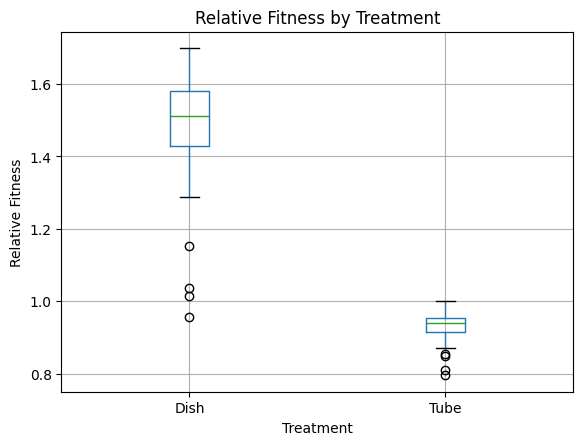

In [24]:
# Create a boxplot to compare RelativeFitness values by Treatment

df.boxplot(column="RelativeFitness", by="Treatment")

# Add chart title and labels
plt.title("Relative Fitness by Treatment")
plt.suptitle("")
plt.xlabel("Treatment")
plt.ylabel("Relative Fitness")

# Display the plot
plt.show()

## Step 9: Save Summary Results

The summary tables are saved as CSV files so they can be used as supporting results for the final Word report.

In [25]:
# Save the treatment describe summary as a CSV file

treatment_summary.round(4).to_csv("treatment_describe_summary.csv")

In [26]:
# Save the aggregation summary as a CSV file

treatment_agg.round(4).to_csv("treatment_aggregation_summary.csv")

In [27]:
# Save the group treatment comparison table as a CSV file

group_treatment_mean_table.round(4).to_csv("group_treatment_mean_comparison.csv")

In [28]:
# Confirm that the output files were created

print("Summary result files have been saved successfully.")

Summary result files have been saved successfully.
